# ST-GCN: Spatial Temporal Graph Convolutional Network

In [58]:
# Librerías necesarias
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import train_test_split

# Implementación de la arquitectura

## Definición de la Capa de Convolución Espacial (GCN)

In [59]:
class SpatialGraphConv(nn.Module):
    def __init__(self, in_channels, out_channels, A_partitions):
        super().__init__()
        self.K = len(A_partitions)  # Número de particiones (K=3)
        self.convs = nn.ModuleList([
            nn.Conv2d(in_channels, out_channels, kernel_size=1) 
            for _ in range(self.K)
        ])
        self.register_buffer('A', A_partitions) # A_partitions es la matriz A normalizada

    def forward(self, x):
        # x tiene forma (N, C_in, T, V), donde V=33 (keypoints)
        output = None
        for k in range(self.K):
            # 1. Multiplicación del feature map por la matriz A_k
            # torch.einsum realiza (N, C_in, T, V) @ (V, V) -> (N, C_in, T, V)
            # donde V x V es la matriz A_k (aplicando la adyacencia)
            x_neighbor = torch.einsum('nctv,vw->nctw', (x, self.A[k]))
            
            # 2. Convolución 1x1 (aplicando W_k)
            z = self.convs[k](x_neighbor) 

            # 3. Sumar los resultados de las K particiones
            output = z if output is None else output + z
        
        return output

## Definición de la Capa de Convolución Temporal (TCN)

In [66]:
class STGCN_Block(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, A_partitions):
        super().__init__()
        
        T_kernel, V_kernel = kernel_size # V_kernel siempre será 1

        # Módulo de Convolución Espacial
        self.gcn = SpatialGraphConv(out_channels, out_channels, A_partitions)
        
        # Convolución Temporal 2D (solo en el eje del tiempo)
        self.tcn = nn.Conv2d(
            in_channels, 
            out_channels, 
            kernel_size=(T_kernel, 1), 
            padding=(T_kernel // 2, 0)
        )
        
        
        # Capa residual para la conexión skip
        self.residual = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        # x tiene forma (N, C_in, T, V)

        # 1. Conexión Residual
        res = self.residual(x)

        # 2. Módulo TCN (Temporal)
        tcn_out = self.tcn(x) # tcn_out tiene forma (N, C_out, T, V)
        tcn_out = nn.ReLU()(tcn_out)
        
        # 3. Módulo GCN (Espacial)
        # El GCN ahora recibe los features temporales procesados
        st_out = self.gcn(tcn_out)
        
        # 4. SUMA FINAL
        return nn.ReLU()(st_out + res)

In [67]:
class STGCN_Model(nn.Module):
    def __init__(self, num_classes, A_partitions):
        super().__init__()
        
        # Parámetros fijos para MediaPipe Pose (x, y)
        self.C = 2 # Coordenadas x, y
        self.V = 33 # Keypoints/Nodos
        
        # El resto de la arquitectura STGCN sigue igual
        # Asumimos que el primer bloque STGCN recibe 2 canales (x, y)
        self.st_gcn_stack = nn.Sequential(
            STGCN_Block(self.C, 64, (9, 1), A_partitions),
            STGCN_Block(64, 64, (9, 1), A_partitions),
            STGCN_Block(64, 128, (9, 1), A_partitions),
            # ... otros bloques ...
        )

        self.out_channels = 128 
        self.classifier = nn.Linear(self.out_channels, num_classes)

    # ----------------------------------------------------
    # MÉTODOS PRIVADOS PARA DESACOPLAR FUNCIONALIDADES
    # ----------------------------------------------------

    def _create_mask(self, x_in):
        """ Genera la máscara (N, T) a partir de los ceros de padding. """
        sum_features = torch.sum(x_in, dim=2) 
        mask = (sum_features != 0)
        return mask.float()
    
    def _prep_input(self, x_in):
        """ Realiza el Reshape y Permute para preparar el tensor para ST-GCN. """
        N, T, F = x_in.shape
        
        # Reshape: (N, T, 66) -> (N, T, C, V)
        x = x_in.reshape(N, T, self.C, self.V) 
        
        # Permute: (N, T, C, V) -> (N, C, T, V)
        x = x.permute(0, 2, 1, 3) 
        return x

    def _pool_and_classify(self, x, mask):
        """ Aplica Global Average Pooling con masking y realiza la clasificación final. """
        
        # 1. Preparar la Máscara para Broadcasting (N, 1, T, 1)
        mask_4d = mask.unsqueeze(1).unsqueeze(3) 
        
        # 2. Aplicar Máscara y Sumar
        # Multiplicamos la salida final por la máscara para anular el padding
        x_masked = x * mask_4d
        sum_features = x_masked.sum(dim=(2, 3)) # Suma sobre T y V -> (N, C_out)

        # 3. Normalizar (Contar Nodos Válidos)
        valid_frames_count = mask.sum(dim=1) # Suma sobre T -> Forma (N,)
        total_valid_nodes = (valid_frames_count * self.V).unsqueeze(1) # Forma (N, 1)
        
        # 4. Calcular el Promedio Válido (Evitando división por cero)
        x_pooled = sum_features / (total_valid_nodes + 1e-8) 

        # 5. Clasificar
        return self.classifier(x_pooled)

    # ----------------------------------------------------
    # F U N C I Ó N   F O R W A R D   (LIMPIA)
    # ----------------------------------------------------
    def forward(self, x_in):
        # x_in tiene la forma (N, T, 66)

        # 1. Preprocesamiento: Generar la máscara y reestructurar el tensor
        mask = self._create_mask(x_in)
        x = self._prep_input(x_in)

        # 2. Procesamiento Núcleo ST-GCN
        # NOTA: Los bloques TCN/GCN dentro del Sequential NO necesitan el masking
        # ya que la pérdida por el padding se corrige en el pooling final.
        x = self.st_gcn_stack(x)
        
        # 3. Post-procesamiento: Pooling y Clasificación
        return self._pool_and_classify(x, mask)

1. **Preparación y Formato de los Datos.**

El formato de entrada para ST-GCN es crucial y difiere de los DataFrames planos que tienes. Necesitas convertir tus datos en un tensor con las dimensiones específicas que la red convolucional maneja.

*Reestructurar los Datos*: Toma tus landmarks originales (o los ángulos, si los prefieres, aunque ST-GCN funciona mejor con coordenadas) para cada secuencia (ejemplo de flexión).
    * Un conjunto de datos de pose (coordenadas $x, y$) debe tener la forma:$$\text{Input: } (\mathbf{N}, \mathbf{C}, \mathbf{T}, \mathbf{V})$$$\mathbf{N}$: Número de secuencias (el batch size).$\mathbf{C}$: Canales (features por nodo, típicamente 2 para $(x, y)$ o 3 para $(x, y, z)$).$\mathbf{T}$: Dimensión temporal (número de frames en la secuencia).$\mathbf{V}$: Nodos (keypoints o articulaciones, 33 para MediaPipe Pose).

Ventana de Tiempo (Sequence Truncation):Dado que las secuencias de ejercicio pueden tener diferentes longitudes, es común cortarlas o padearlas a una longitud fija $\mathbf{T}$ (ej., 50 frames). Esto asegura que todos los tensors de entrada tengan la misma forma.Matriz de Adyacencia ($A$):Debes crear y normalizar la matriz $33 \times 33$ que define las conexiones esqueléticas. Esta matriz se alimenta al modelo y se usa en cada capa GCN.

### Construcción de la matriz de adyacencia

In [68]:
import numpy as np

def build_mediapipe_adjacency_matrix(num_keypoints=33):
    """
    Construye la matriz de adyacencia (A_ADJ) para los 33 keypoints de MediaPipe Pose.
    """
    
    # Definición de los bordes del esqueleto (pares de índices conectados)
    # Se incluyen conexiones para cabeza/ojos/orejas para una matriz de 33 nodos.
    # Esta lista de bordes define la estructura de las extremidades y el tronco.
    EDGES = [
        # Cabeza y Tronco Central
        (0, 1), (1, 2), (2, 3), (3, 7), (4, 5), (5, 6), (6, 8), # Ojos, Nariz, Orejas
        (9, 10), (11, 12), (23, 24), # Boca, Hombros, Caderas
        
        # Conexiones Hombro/Cadera/Tronco
        (11, 23), (12, 24), (11, 12), (23, 24), # Tronco (Hombro-Cadera, Hombro-Hombro, Cadera-Cadera)

        # Brazo Izquierdo
        (11, 13), (13, 15), (15, 17), (17, 19), (19, 21), # Hombro I -> Muñeca I -> Dedos
        
        # Brazo Derecho
        (12, 14), (14, 16), (16, 18), (18, 20), (20, 22), # Hombro D -> Muñeca D -> Dedos
        
        # Pierna Izquierda
        (23, 25), (25, 27), (27, 29), (29, 31), # Cadera I -> Pie I
        
        # Pierna Derecha
        (24, 26), (26, 28), (28, 30), (30, 32), # Cadera D -> Pie D
        
        # Conexión cruzada entre lados (muñecas)
        (15, 17), (16, 18),
    ]

    # Inicializar la matriz de adyacencia (33x33) con ceros
    A_ADJ = np.zeros((num_keypoints, num_keypoints), dtype=np.float32)

    # Llenar la matriz con las conexiones (bordes)
    for i, j in EDGES:
        # Poner 1 para la conexión (i -> j) y (j -> i) (grafo no dirigido)
        if 0 <= i < num_keypoints and 0 <= j < num_keypoints:
            A_ADJ[i, j] = 1.0
            A_ADJ[j, i] = 1.0

    return A_ADJ

# Generar la matriz de adyacencia
A_ADJ_RAW = build_mediapipe_adjacency_matrix()

print(f"La matriz de adyacencia RAW tiene forma: {A_ADJ_RAW.shape}")

La matriz de adyacencia RAW tiene forma: (33, 33)


### Matriz de particiones para ST-GCN

In [69]:
def normalize_adjacency(A_adj):
    """
    Calcula la matriz de adyacencia normalizada simétrica (D^-1/2 * A' * D^-1/2).
    """
    # 1. Añadir el lazo propio (self-loop): A' = A + I
    A_prime = A_adj + np.eye(A_adj.shape[0])
    
    # 2. Calcular la matriz de grado D (suma de filas)
    D = np.sum(A_prime, axis=1)
    
    # 3. Calcular D^-1/2
    D_half_norm = np.diag(D ** (-0.5))
    
    # 4. Calcular A_norm = D^-1/2 * A' * D^-1/2
    A_norm = D_half_norm @ A_prime @ D_half_norm
    
    # Devolver como tensor PyTorch (asumiendo que STGCN_Model usa K=1 partición)
    return torch.tensor(A_norm, dtype=torch.float32)

# La matriz A normalizada para un modelo K=1:
A_NORM_TENSOR = normalize_adjacency(A_ADJ_RAW)

# Para usar en el modelo STGCN_Model_Adapted (con K=1), pasaríamos un tensor de forma (1, V, V)
A_PARTITIONS_K1 = A_NORM_TENSOR.unsqueeze(0) 

print(f"\nLa matriz normalizada (para K=1) tiene forma: {A_PARTITIONS_K1.shape}")


La matriz normalizada (para K=1) tiene forma: torch.Size([1, 33, 33])


### Ejemplo de uso del modelo

In [70]:
import torch
import torch.nn as nn
import numpy as np
# Necesitas las clases SpatialGraphConv, STGCN_Block, STGCN_Model definidas previamente
# (Asumiendo que las has cargado o copiado en tu entorno)

# --- Definición de clases (Simplificada para el ejemplo) ---
# En un script real, estas clases deben estar definidas, las hemos omitido aquí
# para concentrarnos en la simulación I/O.
# (Puedes usar la definición anterior para las clases STGCN_Block, SpatialGraphConv, y STGCN_Model)
# -----------------------------------------------------------

# 1. Definición de Parámetros de Entrada
BATCH_SIZE = 32
CHANNELS = 2     # x, y coordinates
TIME_STEPS = 50  # 50 frames per sequence
VERTICES = 33    # 33 MediaPipe keypoints
NUM_CLASSES = 2  # 0: Incorrecto, 1: Correcto

# 2. Simulación de la Matriz de Adyacencia (A)
# ST-GCN usa múltiples particiones de A. Aquí simulamos una simple matriz de 3 particiones (K=3).
# En un entorno real, A_PARTITIONS debe ser una matriz de adyacencia real, normalizada y triparticionada.
A_ADJ = torch.eye(VERTICES) # Matriz identidad para simular auto-conexión
A_PARTITIONS = torch.stack([A_ADJ, A_ADJ, A_ADJ], dim=0) # Forma (K, V, V) -> (3, 33, 33)

# 3. Creación del Tensor de Entrada Simulada (X)
# Generamos datos aleatorios con la forma requerida: (N, C, T, V)
# Estos datos simularían 32 secuencias de 50 frames, cada frame con 33 keypoints (x, y).
X_simulated = torch.randn(BATCH_SIZE, TIME_STEPS, VERTICES * CHANNELS)
print(f"Shape de la Entrada X: {X_simulated.shape}")

# 4. Inicialización del Modelo
# (Requiere que las clases STGCN estén definidas)
try:
    model = STGCN_Model(
        num_classes=NUM_CLASSES, 
        A_partitions=A_PARTITIONS
    )
    print("Modelo ST-GCN inicializado correctamente.")
    
    # 5. Paso Adelante (Forward Pass)
    output = model(X_simulated)
    
    # 6. Salida del Modelo (Predicciones)
    print(f"Shape de la Salida Y: {output.shape}")
    
    # Ejemplo de la primera predicción del batch
    print("\nPredicción de la primera secuencia (Logits/Scores):")
    print(output[0])
    
    # Aplicar Softmax para obtener probabilidades
    probabilities = nn.Softmax(dim=1)(output)
    
    # La clase predicha es el índice con la probabilidad más alta
    predicted_class = torch.argmax(probabilities, dim=1)
    
    print("\nProbabilidades de las 3 primeras secuencias:")
    print(probabilities[:3])
    print(f"Clase Predicha para las 3 primeras secuencias: {predicted_class[:3].tolist()}")

except NameError as e:
    print("\n⚠️ Por favor, asegúrate de que las clases 'SpatialGraphConv', 'STGCN_Block', y 'STGCN_Model' de la respuesta anterior estén definidas en tu script antes de ejecutar la simulación.")
    raise e

Shape de la Entrada X: torch.Size([32, 50, 66])
Modelo ST-GCN inicializado correctamente.
Shape de la Salida Y: torch.Size([32, 2])

Predicción de la primera secuencia (Logits/Scores):
tensor([-0.1405,  0.0333], grad_fn=<SelectBackward0>)

Probabilidades de las 3 primeras secuencias:
tensor([[0.4567, 0.5433],
        [0.4571, 0.5429],
        [0.4569, 0.5431]], grad_fn=<SliceBackward0>)
Clase Predicha para las 3 primeras secuencias: [1, 1, 1]


## Entrenamiento del modelo

### Implementación del dataset y el dataloader

In [71]:
%pwd

'c:\\Users\\Víctor\\OneDrive - UNIVERSIDAD DE MURCIA\\4º CID\\EML-BLOQUE-II\\push-up-video-classification'

In [72]:
# Cargamos los numpy arrays guardados
X_correct = np.load('./Data/Processed/correct_push_ups_landmarks.npy')
X_incorrect = np.load('./Data/Processed/wrong_push_ups_landmarks.npy')

X = np.vstack((X_correct, X_incorrect))
y = np.array([1]*X_correct.shape[0] + [0]*X_incorrect.shape[0])  

# Convertir a tensores de PyTorch
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long) # Las etiquetas de clasificación deben ser LONG

In [73]:
X_train, X_val, y_train, y_val = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42
)

In [74]:
BATCH_SIZE = 32 # Número de secuencias por lote

# Crea el objeto Dataset (combina X y Y)
train_dataset = TensorDataset(X_train, y_train)

# Crea el DataLoader (se encarga de iterar, barajar y cargar por lotes)
train_dataloader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True # Barajar los datos en cada época para evitar sesgos
)

# Puedes hacer lo mismo para el conjunto de validación
val_dataset = TensorDataset(X_val, y_val)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Número de lotes de entrenamiento: {len(train_dataloader)}")

Número de lotes de entrenamiento: 3


In [75]:
import torch

# Define el dispositivo de ejecución
# Si CUDA (NVIDIA GPU) está disponible, usa la GPU; si no, usa la CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Usando dispositivo: {device}")

# Asegúrate de enviar tu modelo al dispositivo
# model.to(device)

Usando dispositivo: cpu


In [77]:
import matplotlib.pyplot as plt
import numpy as np
# Necesitas también el 'val_dataloader' (cargador de datos de validación)

# --- INICIALIZACIÓN DE LISTAS ---
train_losses = []
val_losses = [] # Para almacenar la pérdida de validación

# Inicialización
NUM_EPOCHS = 20
LR = 5*1e-4
model = STGCN_Model(num_classes=2, A_partitions=A_PARTITIONS).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)


for epoch in range(NUM_EPOCHS):
    
    # ----------------------------------------
    # FASE DE ENTRENAMIENTO
    # ----------------------------------------
    model.train() 
    epoch_train_loss = 0
    
    for inputs, labels in train_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # 1. Acumular la pérdida
        epoch_train_loss += loss.item() * inputs.size(0) 

        loss.backward() 
        optimizer.step()
    
    # Calcular la pérdida promedio de entrenamiento por época
    avg_train_loss = epoch_train_loss / len(train_dataloader.dataset)
    train_losses.append(avg_train_loss)
    
    # ----------------------------------------
    # FASE DE VALIDACIÓN (Crucial para detectar Overfitting)
    # ----------------------------------------
    model.eval() # Pone el modelo en modo evaluación (desactiva dropout/batchnorm)
    epoch_val_loss = 0
    
    with torch.no_grad(): # Desactiva el cálculo de gradientes para ahorrar memoria y tiempo
        for inputs_val, labels_val in val_dataloader:
            inputs_val, labels_val = inputs_val.to(device), labels_val.to(device)
            
            outputs_val = model(inputs_val)
            loss_val = criterion(outputs_val, labels_val)
            
            # 2. Acumula la pérdida de validación
            epoch_val_loss += loss_val.item() * inputs_val.size(0)
            
    # Calcular la pérdida promedio de validación por época
    avg_val_loss = epoch_val_loss / len(val_dataloader.dataset)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

Epoch 1/20, Train Loss: 0.6932, Val Loss: 0.7132
Epoch 2/20, Train Loss: 0.6977, Val Loss: 0.6876
Epoch 3/20, Train Loss: 0.6989, Val Loss: 0.6829
Epoch 4/20, Train Loss: 0.6879, Val Loss: 0.6929
Epoch 5/20, Train Loss: 0.6844, Val Loss: 0.6961
Epoch 6/20, Train Loss: 0.6818, Val Loss: 0.6864
Epoch 7/20, Train Loss: 0.6769, Val Loss: 0.6880
Epoch 8/20, Train Loss: 0.6690, Val Loss: 0.6692
Epoch 9/20, Train Loss: 0.6680, Val Loss: 0.6732
Epoch 10/20, Train Loss: 0.6487, Val Loss: 0.7065
Epoch 11/20, Train Loss: 0.6492, Val Loss: 0.6479
Epoch 12/20, Train Loss: 0.6540, Val Loss: 0.6336
Epoch 13/20, Train Loss: 0.6380, Val Loss: 0.6943
Epoch 14/20, Train Loss: 0.6180, Val Loss: 0.6160
Epoch 15/20, Train Loss: 0.6038, Val Loss: 0.6281
Epoch 16/20, Train Loss: 0.5714, Val Loss: 0.6124
Epoch 17/20, Train Loss: 0.5471, Val Loss: 0.5894
Epoch 18/20, Train Loss: 0.5622, Val Loss: 0.7135
Epoch 19/20, Train Loss: 0.5600, Val Loss: 0.5923
Epoch 20/20, Train Loss: 0.5384, Val Loss: 0.6998


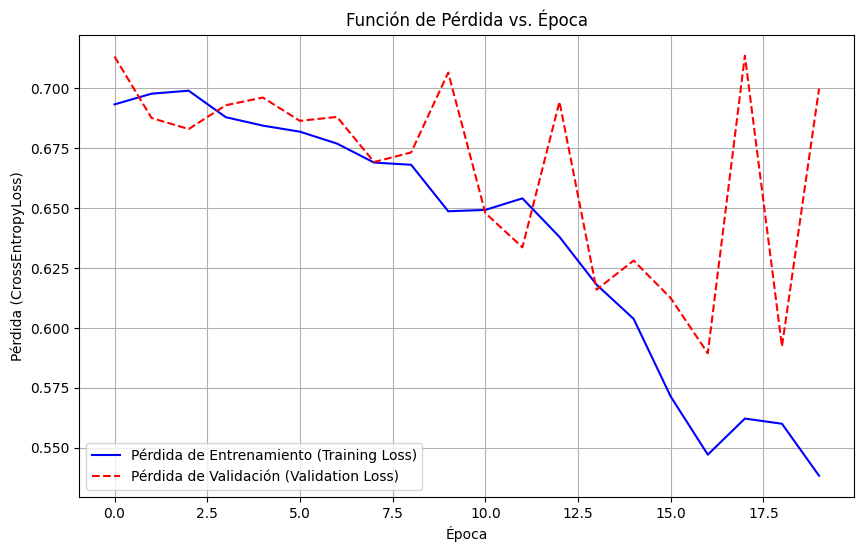

In [78]:
## --- CÓDIGO DE VISUALIZACIÓN ---

plt.figure(figsize=(10, 6))

# Trazar la pérdida de entrenamiento
plt.plot(train_losses, label='Pérdida de Entrenamiento (Training Loss)', color='blue')

# Trazar la pérdida de validación
plt.plot(val_losses, label='Pérdida de Validación (Validation Loss)', color='red', linestyle='--')

# Configuración del gráfico
plt.title('Función de Pérdida vs. Época')
plt.xlabel('Época')
plt.ylabel('Pérdida (CrossEntropyLoss)')
plt.legend()
plt.grid(True)
plt.show()